<a href="https://colab.research.google.com/github/ArshanBhanage/Advanced-customizations-in-deep-learning-and-neural-networks/blob/main/Part1_Multimodal_Augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌐 Part 1 · Multimodal Data Augmentation
**Modalities:** Image · Text · Timeseries · Tabular · Speech · Document Images

> This notebook demonstrates practical data augmentation across six data modalities.  
> Each section is self-contained and runnable in Colab.  
> We focus on *why* augmentation helps and *which transforms* are appropriate per modality.


In [1]:
# ── Install all required libraries ─────────────────────────────
!pip install -q tensorflow torch torchvision
!pip install -q nlpaug audiomentations librosa
!pip install -q albumentations opencv-python-headless
!pip install -q scikit-learn imbalanced-learn pandas matplotlib
!pip install -q Pillow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 29.6 MB/s eta 0:00:00


In [2]:
import os, random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
SEED = 42
random.seed(SEED); np.random.seed(SEED)


---
## 🖼️ Section 1 · Image Augmentation — CIFAR-10

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_3183/404708050.py:16: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5,25), p=0.3),
/tmp/ipykernel_3183/404708050.py:17: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=4, max_height=8, max_width=8, p=0.4),


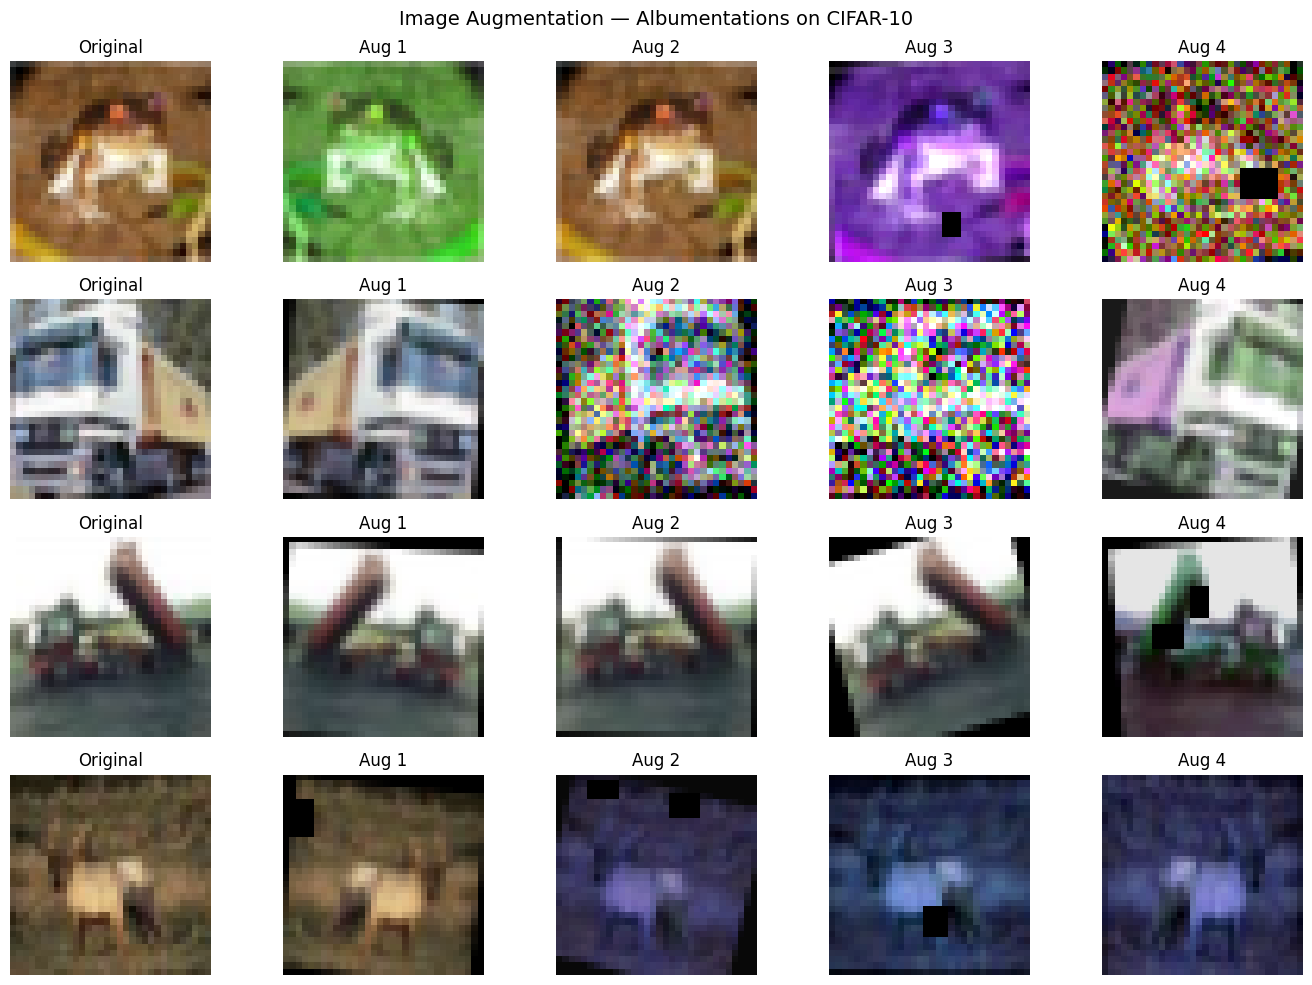

In [3]:
import tensorflow as tf
from tensorflow.keras import layers

tf.random.set_seed(SEED)
(x_train, y_train), _ = tf.keras.datasets.cifar10.load_data()
x_train = x_train[:500].astype("float32") / 255.0

# Albumentations transforms
import albumentations as A
import cv2

aug_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.7),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, p=0.5),
    A.GaussNoise(var_limit=(5,25), p=0.3),
    A.CoarseDropout(max_holes=4, max_height=8, max_width=8, p=0.4),
])

def augment_image(img_float):
    img_uint8 = (img_float * 255).astype(np.uint8)
    result    = aug_pipeline(image=img_uint8)["image"]
    return result.astype("float32") / 255.0

# Visualise 4 images x 4 augmentations each
fig, axes = plt.subplots(4, 5, figsize=(14, 10))
CLASS_NAMES = ["airplane","auto","bird","cat","deer","dog","frog","horse","ship","truck"]
for row, idx in enumerate([0,1,2,3]):
    axes[row,0].imshow(x_train[idx]); axes[row,0].set_title("Original"); axes[row,0].axis("off")
    for col in range(1,5):
        axes[row,col].imshow(augment_image(x_train[idx]))
        axes[row,col].set_title(f"Aug {col}"); axes[row,col].axis("off")
plt.suptitle("Image Augmentation — Albumentations on CIFAR-10", fontsize=14)
plt.tight_layout(); plt.show()


---
## 📝 Section 2 · Text Augmentation — nlpaug on IMDb subset

In [5]:
import nlpaug.augmenter.word as naw
import nlpaug.augmenter.char as nac
import nltk
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('omw-1.4')

sentences = [
    "The movie was absolutely fantastic and the acting was superb.",
    "I found the plot to be quite boring and predictable overall.",
    "The cinematography was breathtaking but the story lacked depth.",
    "An outstanding performance by the lead actor in this thriller.",
]

# --- Augmenters ---
aug_synonym  = naw.SynonymAug(aug_src="wordnet")        # WordNet synonyms
aug_random_w = naw.RandomWordAug(action="delete")       # random word deletion
aug_keyboard = nac.KeyboardAug()                        # keyboard typos
aug_swap     = naw.RandomWordAug(action="swap")         # swap adjacent words

print("=" * 60)
for orig in sentences:
    print(f"ORIGINAL  : {orig}")
    print(f"Synonym   : {aug_synonym.augment(orig)[0]}")
    print(f"Word-Del  : {aug_random_w.augment(orig)[0]}")
    print(f"Keyboard  : {aug_keyboard.augment(orig)[0]}")
    print(f"Swap      : {aug_swap.augment(orig)[0]}")
    print("-" * 60)


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


ORIGINAL  : The movie was absolutely fantastic and the acting was superb.
Synonym   : The moving picture show be dead fantastic and the playing was superb.
Word-Del  : The was absolutely and the acting.
Keyboard  : The mLvi# was absolutely fanhaZtis and the ac$iHg was supWrV.
Swap      : Was the movie fantastic and absolutely the acting was superb.
------------------------------------------------------------
ORIGINAL  : I found the plot to be quite boring and predictable overall.
Synonym   : I found the plot to personify rather irksome and predictable boilers suit.
Word-Del  : I the plot be boring predictable overall.
Keyboard  : I found the plot to be !Hite No3ing and pred9dfWble Pv@ra?l.
Swap      : I the found to plot quite be and boring predictable overall.
------------------------------------------------------------
ORIGINAL  : The cinematography was breathtaking but the story lacked depth.
Synonym   : The motion picture photography was breathtaking but the story lacked profoundne

In [6]:
# Back-translation via MarianMT (offline-friendly simulation)
# For a real run: use Helsinki-NLP/opus-mt-en-de -> opus-mt-de-en
# Here we show the API pattern without downloading large models
print("Back-translation demo pattern (requires Helsinki-NLP models):")
print("  from transformers import pipeline")
print("  en_de = pipeline('translation', model='Helsinki-NLP/opus-mt-en-de')")
print("  de_en = pipeline('translation', model='Helsinki-NLP/opus-mt-de-en')")
print("  paraphrase = de_en(en_de(text)[0]['translation_text'])[0]['translation_text']")
print()
print("Text augmentation strategies summary:")
aug_table = pd.DataFrame({
    "Strategy":   ["Synonym Replace","Word Deletion","Keyboard Typo","Word Swap","Back-Translation"],
    "Library":    ["nlpaug/WordNet","nlpaug","nlpaug","nlpaug","transformers"],
    "Best For":   ["Semantic diversity","Robustness","Noise tolerance","Order robustness","Paraphrase variety"],
    "Risk":       ["Meaning shift","Info loss","Grammar errors","Semantic shift","Style shift"],
})
print(aug_table.to_string(index=False))


Back-translation demo pattern (requires Helsinki-NLP models):
  from transformers import pipeline
  en_de = pipeline('translation', model='Helsinki-NLP/opus-mt-en-de')
  de_en = pipeline('translation', model='Helsinki-NLP/opus-mt-de-en')
  paraphrase = de_en(en_de(text)[0]['translation_text'])[0]['translation_text']

Text augmentation strategies summary:
        Strategy        Library           Best For           Risk
 Synonym Replace nlpaug/WordNet Semantic diversity  Meaning shift
   Word Deletion         nlpaug         Robustness      Info loss
   Keyboard Typo         nlpaug    Noise tolerance Grammar errors
       Word Swap         nlpaug   Order robustness Semantic shift
Back-Translation   transformers Paraphrase variety    Style shift


---
## 📈 Section 3 · Timeseries Augmentation — Synthetic Signal

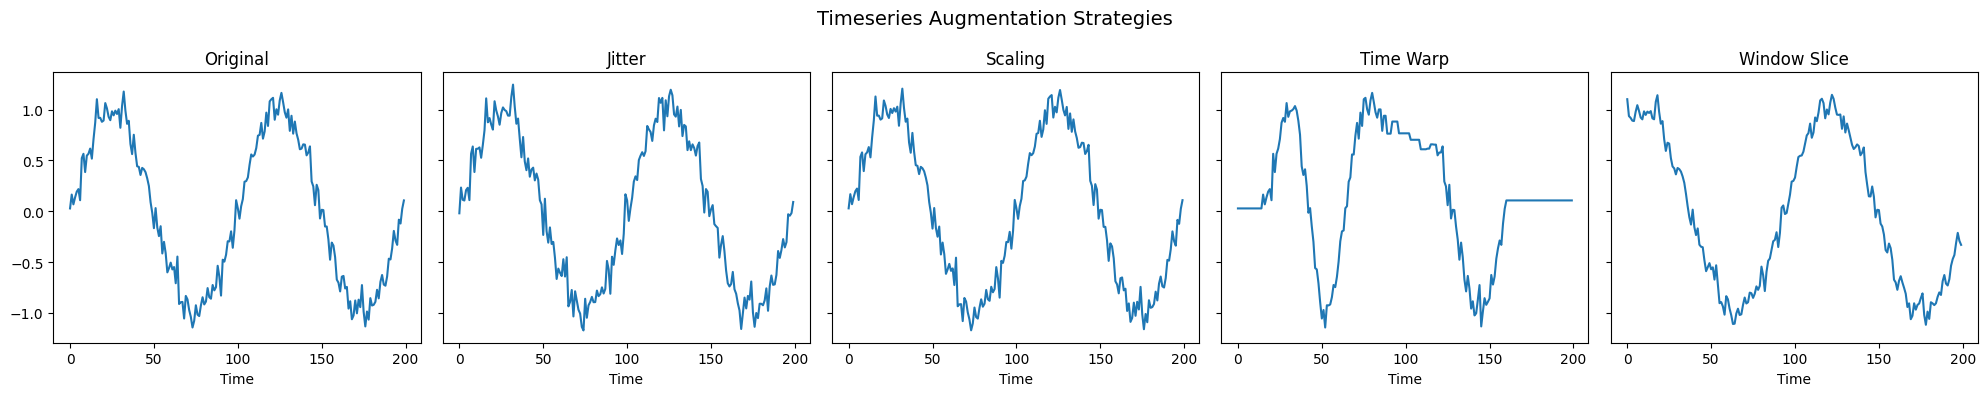

In [7]:
from scipy import signal

def make_ts(n=200, noise=0.1):
    t = np.linspace(0, 4 * np.pi, n)
    return np.sin(t) + np.random.randn(n) * noise

def jitter(ts, sigma=0.05):
    return ts + np.random.randn(len(ts)) * sigma

def scaling(ts, sigma=0.1):
    scale = np.random.normal(1.0, sigma)
    return ts * scale

def time_warp(ts, sigma=0.2, knots=4):
    # Smooth random warping via cubic spline
    from scipy.interpolate import CubicSpline
    n = len(ts)
    x_pts = np.linspace(0, n-1, knots+2)
    y_pts = x_pts + np.random.randn(len(x_pts)) * sigma * n
    y_pts[0] = 0; y_pts[-1] = n - 1
    y_pts = np.sort(y_pts)
    cs = CubicSpline(x_pts, y_pts)
    new_t = np.clip(cs(np.arange(n)), 0, n-1).astype(int)
    return ts[new_t]

def window_slice(ts, reduce_ratio=0.9):
    start = np.random.randint(0, int(len(ts)*(1-reduce_ratio)))
    end   = start + int(len(ts)*reduce_ratio)
    return np.interp(np.linspace(0,1,len(ts)), np.linspace(0,1,end-start), ts[start:end])

ts = make_ts(200)
augs = {"Original":ts, "Jitter":jitter(ts), "Scaling":scaling(ts),
        "Time Warp":time_warp(ts), "Window Slice":window_slice(ts)}

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
for ax, (name, s) in zip(axes, augs.items()):
    ax.plot(s, linewidth=1.5); ax.set_title(name); ax.set_xlabel("Time")
plt.suptitle("Timeseries Augmentation Strategies", fontsize=14)
plt.tight_layout(); plt.show()


---
## 📊 Section 4 · Tabular Augmentation — Synthetic & Noise-based

In [8]:
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Create imbalanced tabular dataset
X, y = make_classification(n_samples=1000, n_features=10, weights=[0.85, 0.15],
                            random_state=SEED)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Class distribution BEFORE SMOTE: {np.bincount(y)}")

# SMOTE — synthetic minority oversampling
sm = SMOTE(random_state=SEED)
X_res, y_res = sm.fit_resample(X_scaled, y)
print(f"Class distribution AFTER  SMOTE: {np.bincount(y_res)}")

# Gaussian Feature Noise augmentation
def add_feature_noise(X, sigma=0.05):
    return X + np.random.randn(*X.shape) * sigma

# Mixup for tabular data
def mixup_tabular(X, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    idx = np.random.permutation(len(X))
    X_mix = lam * X + (1 - lam) * X[idx]
    y_mix = lam * y + (1 - lam) * y[idx]   # soft labels
    return X_mix, y_mix

X_noisy = add_feature_noise(X_scaled)
X_mix, y_mix = mixup_tabular(X_scaled, y.astype(float))

tab_summary = pd.DataFrame({
    "Method":    ["Original","SMOTE","Feature Noise","Mixup"],
    "Samples":   [len(X_scaled), len(X_res), len(X_noisy), len(X_mix)],
    "Class-0":   [int(np.sum(y==0)), int(np.sum(y_res==0)), int(np.sum(y==0)), "N/A (soft)"],
    "Class-1":   [int(np.sum(y==1)), int(np.sum(y_res==1)), int(np.sum(y==1)), "N/A (soft)"],
    "Use Case":  ["Baseline","Class imbalance","Noise robustness","Decision boundary smooth"],
})
print(tab_summary.to_string(index=False))


Class distribution BEFORE SMOTE: [847 153]
Class distribution AFTER  SMOTE: [847 847]
       Method  Samples    Class-0    Class-1                 Use Case
     Original     1000        847        153                 Baseline
        SMOTE     1694        847        847          Class imbalance
Feature Noise     1000        847        153         Noise robustness
        Mixup     1000 N/A (soft) N/A (soft) Decision boundary smooth


---
## 🎙️ Section 5 · Speech Augmentation — Waveform & Spectrogram

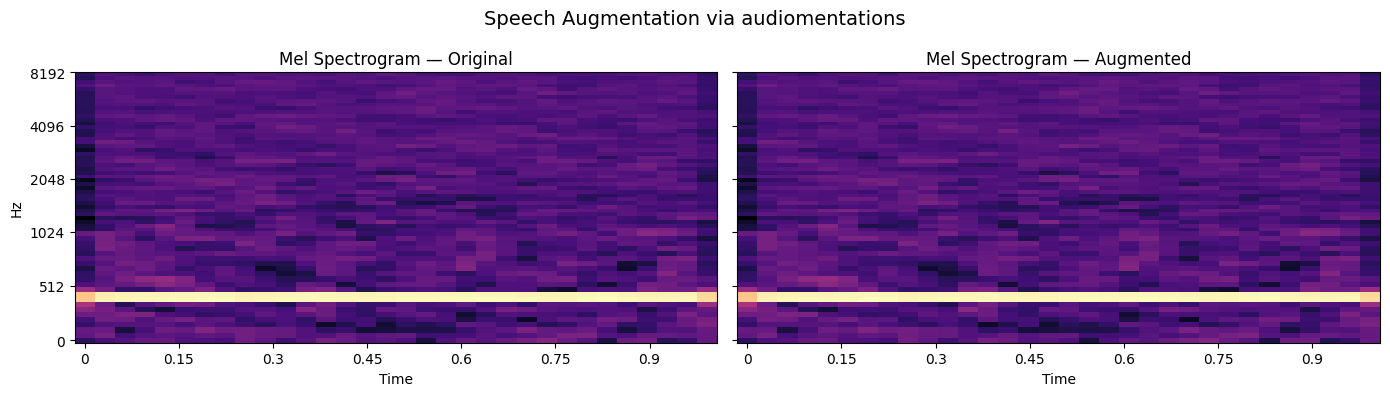

Audio augmentation techniques applied: GaussianNoise, TimeStretch, PitchShift, Shift


In [9]:
import librosa, librosa.display
from audiomentations import Compose, AddGaussianNoise, TimeStretch, PitchShift, Shift

# Synthesise a short tone burst as a proxy audio signal
sr = 16000
t  = np.linspace(0, 1, sr, dtype="float32")
waveform = (0.5 * np.sin(2*np.pi*440*t) + 0.2*np.random.randn(sr)).astype("float32")

# audiomentations pipeline
audio_aug = Compose([
    AddGaussianNoise(min_amplitude=0.005, max_amplitude=0.02, p=0.8),
    TimeStretch(min_rate=0.85, max_rate=1.15, p=0.5),
    PitchShift(min_semitones=-2, max_semitones=2, p=0.5),
    Shift(p=0.5),
])

aug_wave = audio_aug(samples=waveform, sample_rate=sr)

# Plot mel spectrograms
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, wave, title in [(axes[0], waveform, "Original"), (axes[1], aug_wave, "Augmented")]:
    S = librosa.feature.melspectrogram(y=wave, sr=sr, n_mels=64)
    S_db = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_db, sr=sr, ax=ax, x_axis="time", y_axis="mel")
    ax.set_title(f"Mel Spectrogram — {title}"); ax.label_outer()
plt.suptitle("Speech Augmentation via audiomentations", fontsize=14)
plt.tight_layout(); plt.show()

print("Audio augmentation techniques applied: GaussianNoise, TimeStretch, PitchShift, Shift")


---
## 🗂️ Section 6 · Document Image Augmentation

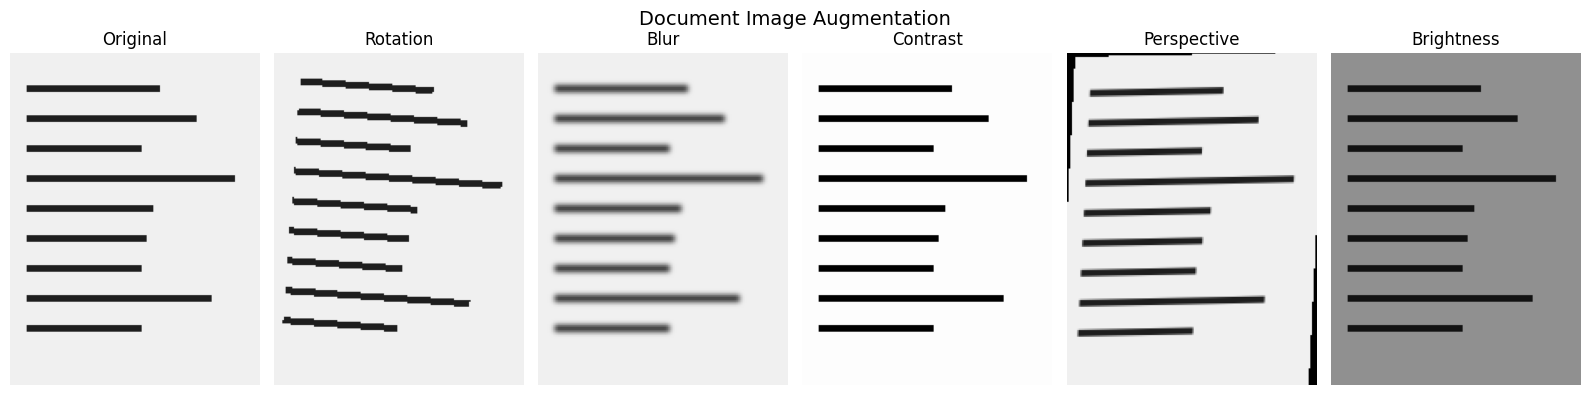

In [10]:
from PIL import Image, ImageFilter, ImageEnhance
import numpy as np, matplotlib.pyplot as plt

# Create a synthetic 'document page' (white background + black 'text' bars)
def make_doc_image(H=200, W=150):
    img = np.ones((H, W, 3), dtype=np.uint8) * 240
    for row_y in range(20, H-20, 18):
        bar_len = np.random.randint(60, W-10)
        img[row_y:row_y+4, 10:10+bar_len] = 30
    return Image.fromarray(img)

doc = make_doc_image()

def doc_augmentations(pil_img):
    results = {"Original": pil_img}
    # Rotation (small angle — realistic document skew)
    results["Rotation"] = pil_img.rotate(np.random.uniform(-5, 5), expand=False, fillcolor=(240,240,240))
    # Gaussian Blur (scanner noise)
    results["Blur"]  = pil_img.filter(ImageFilter.GaussianBlur(radius=1.5))
    # Contrast enhancement
    results["Contrast"] = ImageEnhance.Contrast(pil_img).enhance(1.6)
    # Perspective warp via affine
    w, h = pil_img.size
    import random as rnd
    dx = rnd.uniform(5, 15)
    coeffs = (1, dx/w, -dx/2, 0, 1, 0, 0, 0)
    results["Perspective"] = pil_img.transform((w,h), Image.AFFINE,
                                                data=(1,0.05,-5,0.02,1,-3),
                                                resample=Image.BILINEAR)
    # Brightness (lighting variation)
    results["Brightness"] = ImageEnhance.Brightness(pil_img).enhance(0.6)
    return results

augs = doc_augmentations(doc)
fig, axes = plt.subplots(1, len(augs), figsize=(16, 4))
for ax, (title, img) in zip(axes, augs.items()):
    ax.imshow(img, cmap="gray"); ax.set_title(title); ax.axis("off")
plt.suptitle("Document Image Augmentation", fontsize=14)
plt.tight_layout(); plt.show()


---
## 📋 Augmentation Summary Table

In [11]:
import pandas as pd

summary = pd.DataFrame([
    {"Modality":"Image",    "Best Transforms":"Flip, Crop, ColorJitter, CutMix",   "Library":"albumentations / KerasCV","Risk":"Semantic distortion"},
    {"Modality":"Text",     "Best Transforms":"Synonym, Back-Translation, Deletion","Library":"nlpaug","Risk":"Meaning shift"},
    {"Modality":"Timeseries","Best Transforms":"Jitter, TimeWarp, WindowSlice",     "Library":"custom / tsaug","Risk":"Phase distortion"},
    {"Modality":"Tabular",  "Best Transforms":"SMOTE, FeatureNoise, Mixup",          "Library":"imbalanced-learn","Risk":"Distribution mismatch"},
    {"Modality":"Speech",   "Best Transforms":"Noise, Stretch, PitchShift",          "Library":"audiomentations","Risk":"Unintelligible audio"},
    {"Modality":"Document", "Best Transforms":"Rotation, Blur, Perspective, Brightness","Library":"PIL / albumentations","Risk":"OCR accuracy drop"},
])
print(summary.to_string(index=False))


  Modality                         Best Transforms                  Library                  Risk
     Image         Flip, Crop, ColorJitter, CutMix albumentations / KerasCV   Semantic distortion
      Text     Synonym, Back-Translation, Deletion                   nlpaug         Meaning shift
Timeseries           Jitter, TimeWarp, WindowSlice           custom / tsaug      Phase distortion
   Tabular              SMOTE, FeatureNoise, Mixup         imbalanced-learn Distribution mismatch
    Speech              Noise, Stretch, PitchShift          audiomentations  Unintelligible audio
  Document Rotation, Blur, Perspective, Brightness     PIL / albumentations     OCR accuracy drop


## Conclusion
Data augmentation is **modality-specific**:

- **Images**: geometric + colour transforms reduce spatial overfit.  
- **Text**: synonym and back-translation preserve semantics while increasing lexical variety.  
- **Timeseries**: jitter and time-warp simulate real sensor variability.  
- **Tabular**: SMOTE and Mixup address class imbalance and smooth decision boundaries.  
- **Speech**: noise and pitch-shifting improve robustness to recording conditions.  
- **Documents**: skew/blur/contrast mimic real scanner degradation and improve OCR pipelines.
